In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('car_price_engineered.csv')

df.head()

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD),Powertrain Type,Car Age
0,Porsche,911,2022,3.0,379.0,331.0,4.0,101200.0,ICE,4
1,Lamborghini,Huracan,2021,5.2,630.0,443.0,2.8,274390.0,ICE,5
2,Ferrari,488 GTB,2022,3.9,661.0,561.0,3.0,333750.0,ICE,4
3,Audi,R8,2022,5.2,562.0,406.0,3.2,142700.0,ICE,4
4,McLaren,720S,2021,4.0,710.0,568.0,2.7,298000.0,ICE,5


In [3]:
X, y = df.drop(columns = ['Price (in USD)', 'Year']), df['Price (in USD)']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X train shape: {x_train.shape}")
print(f"X test shape: {x_test.shape}")
print(f"y train shape: {y_train.shape}")
print(f"y test shape: {y_test.shape}")

X train shape: (805, 8)
X test shape: (202, 8)
y train shape: (805,)
y test shape: (202,)


In [4]:
num_col = ['Car Age', 'Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)']
cat_col = ['Car Make', 'Car Model', 'Powertrain Type']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', MinMaxScaler(), num_col),
        ('cat', OneHotEncoder(handle_unknown="ignore"), cat_col)
    ]
)

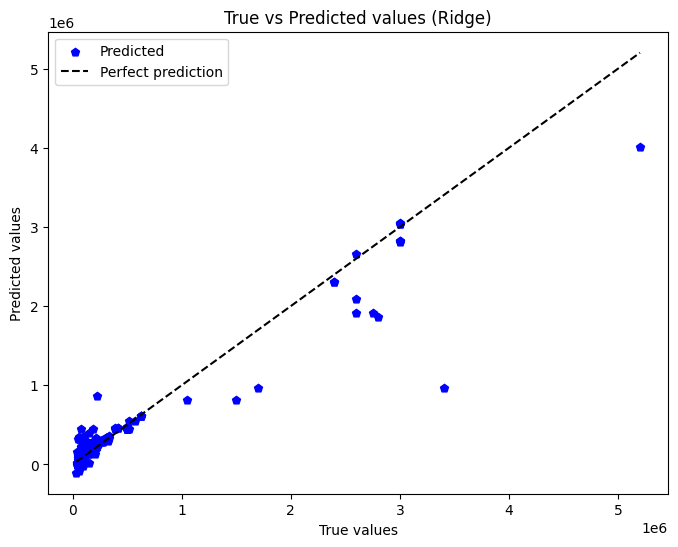

Ridge report:
RMSE: 246493.81190119742
MAE: 88409.18924374928
R2 SCORE: 0.8998471329406371


In [5]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
  ]
)

ridge_pipeline.fit(x_train, y_train)
y_pred_ridge = ridge_pipeline.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, color='blue', marker='p', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='black', linestyle='--', label='Perfect prediction')
plt.title("True vs Predicted values (Ridge)")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.legend()
plt.show()

print("Ridge report:")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_ridge)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge)}")
print(f"R2 SCORE: {r2_score(y_test, y_pred_ridge)}")

In [6]:
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_pipeline.fit(x_train, y_train)
y_pred_linear = linear_pipeline.predict(x_test)

print("Linear Regression report:")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_linear)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_linear)}")
print(f"R2 SCORE: {r2_score(y_test, y_pred_linear)}")

Linear Regression report:
RMSE: 201132.8574529836
MAE: 48633.659364391875
R2 SCORE: 0.9333166527831145


In [7]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(x_train, y_train)
y_pred_rf = rf_pipeline.predict(x_test)


print("Random Forest report:")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_rf)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf)}")
print(f"R2 SCORE: {r2_score(y_test, y_pred_rf)}")

Random Forest report:
RMSE: 282083.70529310504
MAE: 55744.17185522171
R2 SCORE: 0.8688382074123651


In [8]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_pipeline.fit(x_train, y_train)
y_pred_gb = gb_pipeline.predict(x_test)


print("Gradient Boosting report:")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_gb)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_gb)}")
print(f"R2 SCORE: {r2_score(y_test, y_pred_gb)}")

Gradient Boosting report:
RMSE: 281650.8243984281
MAE: 69479.79876592352
R2 SCORE: 0.8692404558812555


In [9]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(random_state=42))
])

xgb_pipeline.fit(x_train, y_train)
y_pred_xgb = xgb_pipeline.predict(x_test)


print("XGBoost report:")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_xgb)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb)}")
print(f"R2 SCORE: {r2_score(y_test, y_pred_xgb)}")

XGBoost report:
RMSE: 253231.68434269825
MAE: 46401.53743811881
R2 SCORE: 0.8942969712295784


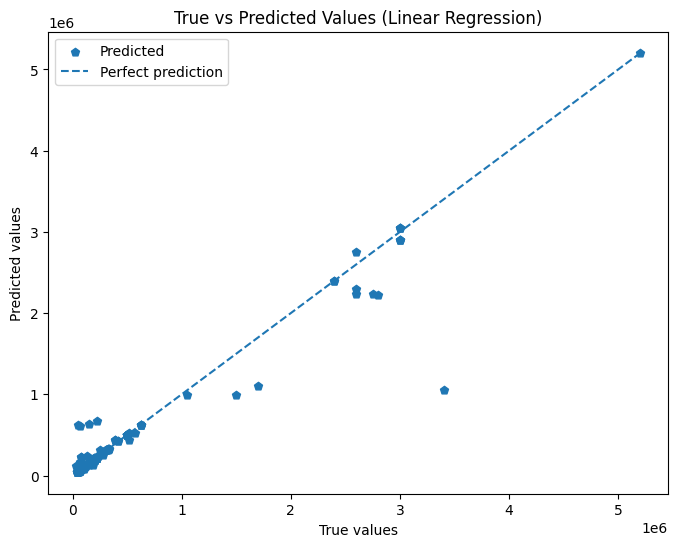

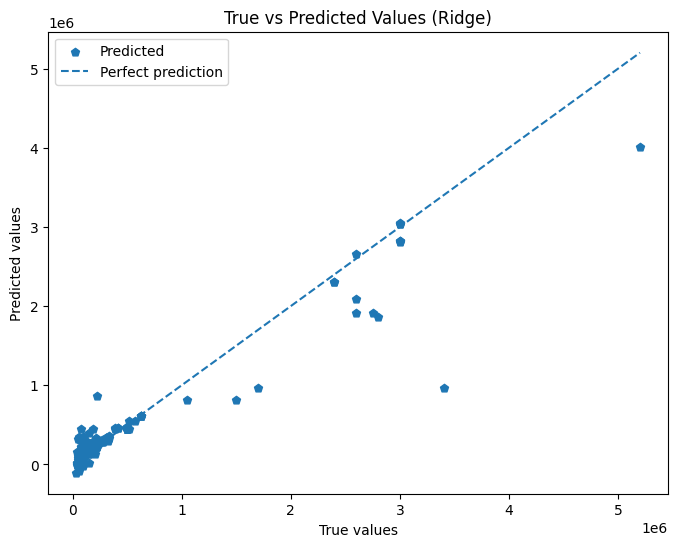

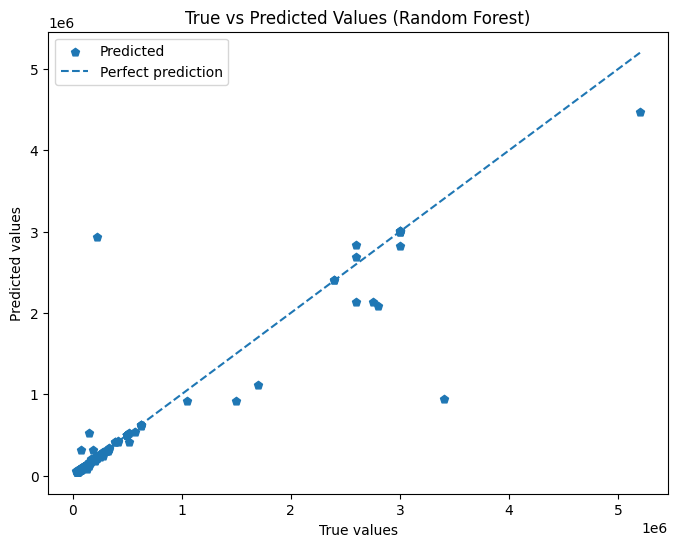

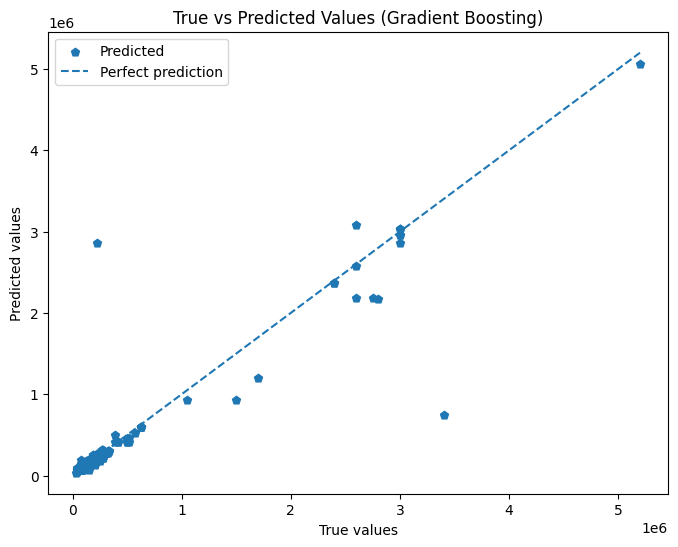

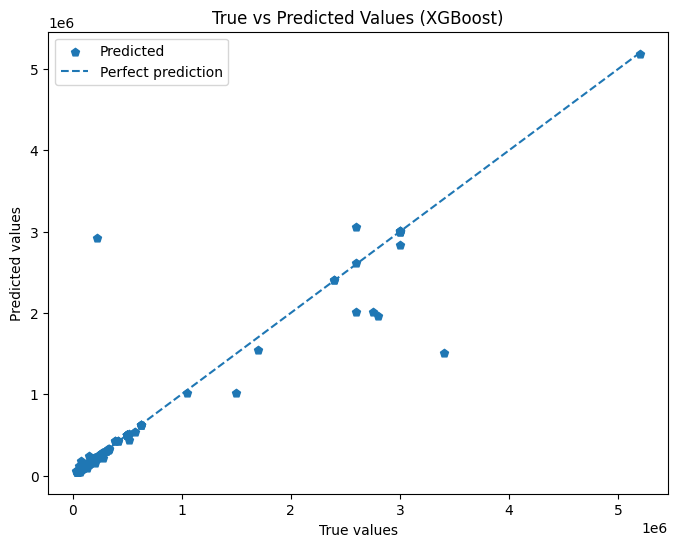

In [10]:
models_predictions = {
    "Linear Regression": y_pred_linear,
    "Ridge": y_pred_ridge,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb
}

for model_name, y_pred in models_predictions.items():

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_test,
        y_pred,
        marker='p',
        label='Predicted'
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--',
        label='Perfect prediction'
    )

    plt.title(f"True vs Predicted Values ({model_name})")
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.legend()
    plt.show()

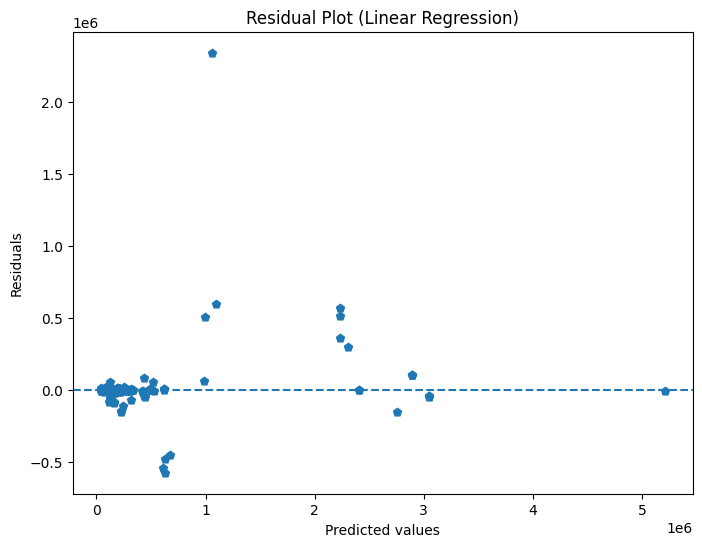

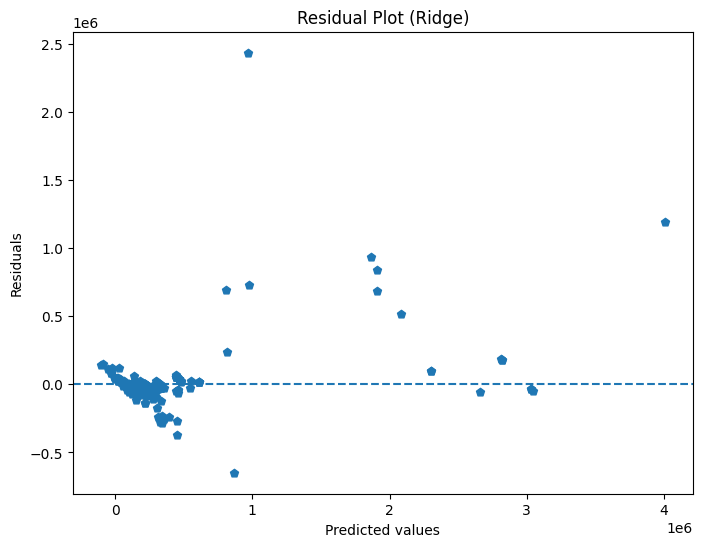

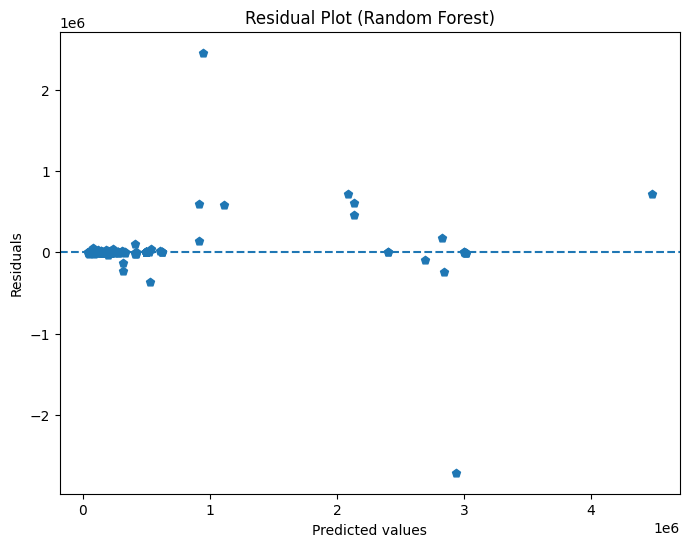

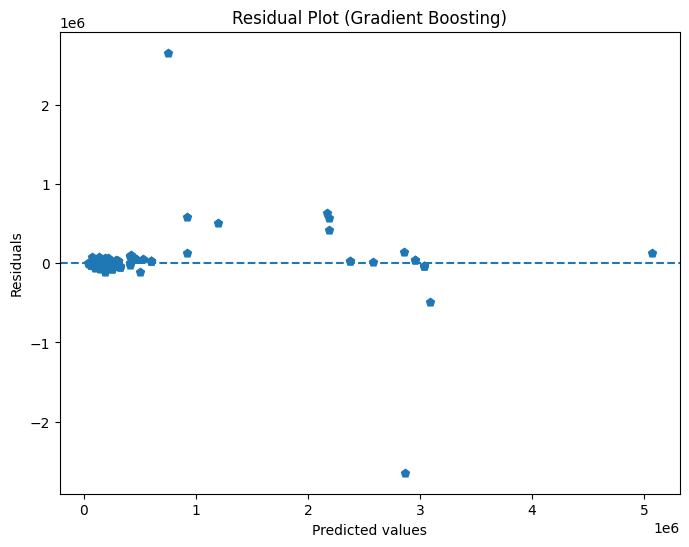

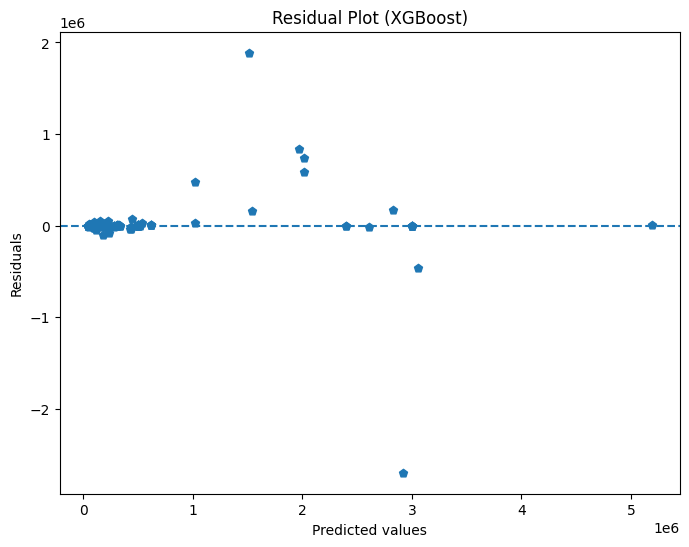

In [11]:
for model_name, y_pred in models_predictions.items():

    residuals = y_test - y_pred

    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_pred,
        residuals,
        marker='p'
    )

    plt.axhline(
        y=0,
        linestyle='--'
    )

    plt.title(f"Residual Plot ({model_name})")
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")

    plt.show()

In [12]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import uniform, randint

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
best_ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',  Ridge())
])

ridge_param = {'model__alpha': uniform(0.01, 10)}

In [14]:
best_gb_pipe = Pipeline([
    ('preprocessor',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_param = {
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(2, 8),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10)
}

In [15]:
best_xgb_pipe = Pipeline([
    ('preprocessor',  preprocessor),
    ('model', xgb.XGBRegressor(
        random_state=42,
        n_job=-1
    ))
])

xgb_param = {
    'model__n_estimators': randint(200, 1200),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(3, 12),
    'model__gamma': uniform(0, 5),
}

In [16]:
searches = {
    'Ridge': (best_ridge_pipe, ridge_param, 30),
    'GradientBoosting': (best_gb_pipe, gb_param, 30),
    'XGBoost': (best_xgb_pipe, xgb_param, 30)
}

In [17]:
best_models = {}
results = []

for name, (pipe, params, n_iter) in searches.items():
    print(f"Tuning {name} ...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=n_iter,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    search.fit(x_train, y_train)

    best_models[name] = search.best_estimator_

    y_pred_train = search.best_estimator_.predict(x_train)
    y_pred_test  = search.best_estimator_.predict(x_test)

    results.append({
        'Model': name,
        'Best Params': search.best_params_,
        'CV RMSE': -search.best_score_,
        'Train RMSE': root_mean_squared_error(y_train, y_pred_train),
        'Test RMSE': root_mean_squared_error(y_test, y_pred_test),
        'Test R2': r2_score(y_test, y_pred_test),
    })

    print(f"Best {name} params: {search.best_params_}")
    print(f"CV RMSE:    {-search.best_score_:.4f}")
    print(f"Test RMSE:  {results[-1]['Test RMSE']:.4f}")
    print(f"Test R2:    {results[-1]['Test R2']:.4f}")

Tuning Ridge ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Ridge params: {'model__alpha': np.float64(0.21584494295802448)}
CV RMSE:    192908.0148
Test RMSE:  206827.4658
Test R2:    0.9295
Tuning GradientBoosting ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best GradientBoosting params: {'model__learning_rate': np.float64(0.19349594814648427), 'model__max_depth': 6, 'model__min_samples_leaf': 9, 'model__min_samples_split': 18}
CV RMSE:    148823.7687
Test RMSE:  308467.9294
Test R2:    0.8432
Tuning XGBoost ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:29:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_job" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'model__gamma': np.float64(0.9111804389403116), 'model__learning_rate': np.float64(0.23660842309529573), 'model__max_depth': 8, 'model__n_estimators': 765}
CV RMSE:    148068.4832
Test RMSE:  265579.3756
Test R2:    0.8837


Model comparison:
           Model       CV RMSE   Train RMSE     Test RMSE  Test R2
           Ridge 192908.014795 61713.228134 206827.465828 0.929487
GradientBoosting 148823.768705 54988.554283 308467.929368 0.843155
         XGBoost 148068.483216 11547.096597 265579.375608 0.883737


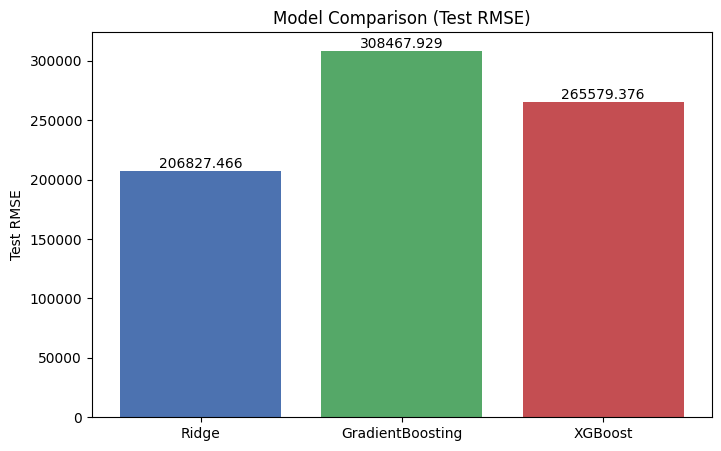

In [18]:
results_df = pd.DataFrame(results)[['Model', 'CV RMSE', 'Train RMSE', 'Test RMSE', 'Test R2']]
print("Model comparison:")
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Test RMSE'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Test RMSE')
plt.title('Model Comparison (Test RMSE)')
for i, v in enumerate(results_df['Test RMSE']):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')
plt.show()

In [19]:
from sklearn.metrics import make_scorer

best_ridge = best_models['Ridge']

cv_2 = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'RMSE': make_scorer(root_mean_squared_error, greater_is_better=False),
    'MAE':  make_scorer(mean_absolute_error, greater_is_better=False),
    'R2':   'r2',
}

In [20]:
models = {
    'Ridge (best)': best_ridge,
    'LinearRegression': linear_pipeline
}

In [21]:
from sklearn.model_selection import cross_validate

summary = []

for name, model in models.items():
    print(f"\n🔁 10-Fold CV for {name} ...")
    scores = cross_validate(
        model,
        x_train, y_train,
        cv=cv_2,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    test_rmse = -scores['test_RMSE']
    test_mae  = -scores['test_MAE']
    test_r2   =  scores['test_R2']

    train_rmse = -scores['train_RMSE']

    summary.append({
        'Model': name,
        'Test RMSE (mean)': test_rmse.mean(),
        'Test RMSE (std)':  test_rmse.std(),
        'Test MAE (mean)':  test_mae.mean(),
        'Test MAE (std)':   test_mae.std(),
        'Test R2 (mean)':   test_r2.mean(),
        'Test R2 (std)':    test_r2.std(),
        'Train RMSE (mean)': train_rmse.mean(),
    })

    print(f"  Fold RMSEs : {np.round(test_rmse, 4)}")
    print(f"  RMSE  = {test_rmse.mean():.4f} ± {test_rmse.std():.4f}")
    print(f"  MAE   = {test_mae.mean():.4f} ± {test_mae.std():.4f}")
    print(f"  R2    = {test_r2.mean():.4f} ± {test_r2.std():.4f}")
    print(f"  Train RMSE = {train_rmse.mean():.4f}")


🔁 10-Fold CV for Ridge (best) ...
  Fold RMSEs : [223987.7793 213084.9126 193113.2154 366520.8488 134750.4692 135386.369
 105823.7311  56208.7202  35368.4569 320491.4074]
  RMSE  = 178473.5910 ± 101729.3641
  MAE   = 48495.6387 ± 15312.8660
  R2    = 0.9267 ± 0.0672
  Train RMSE = 61744.1088

🔁 10-Fold CV for LinearRegression ...
  Fold RMSEs : [235378.1349 213600.2911 204995.515  370697.8754 145928.9121 144564.4861
 104647.1884  50025.9871  36003.3811 323048.074 ]
  RMSE  = 182888.9845 ± 103580.0624
  MAE   = 40203.0520 ± 14667.3899
  R2    = 0.9232 ± 0.0687
  Train RMSE = 49006.1423


In [22]:
summary_df = pd.DataFrame(summary)
print("CV Summary:")
print(summary_df.to_string(index=False))

CV Summary:
           Model  Test RMSE (mean)  Test RMSE (std)  Test MAE (mean)  Test MAE (std)  Test R2 (mean)  Test R2 (std)  Train RMSE (mean)
    Ridge (best)     178473.590992    101729.364064     48495.638724    15312.866044        0.926684       0.067224       61744.108811
LinearRegression     182888.984527    103580.062354     40203.051951    14667.389862        0.923195       0.068652       49006.142323


In [23]:
import joblib

joblib.dump(best_models['Ridge'], 'best_ridge_pipeline.pkl')
print("Best Ridge has been saved: best_ridge_pipeline.pkl")

Best Ridge has been saved: best_ridge_pipeline.pkl


In [24]:
from google.colab import files
files.download('best_ridge_pipeline.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>